In [ ]:
import os, sys, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Input, LSTM, Dense, Dropout, Bidirectional, 
                                     Conv1D, MaxPooling1D, GlobalAveragePooling1D,
                                     BatchNormalization, Activation, Add, 
                                     LayerNormalization, MultiHeadAttention, 
                                     AveragePooling1D)
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.utils import class_weight
from tensorflow.keras.metrics import Precision, Recall
from sklearn.metrics import f1_score, balanced_accuracy_score
from tensorflow.keras.callbacks import Callback

In [ ]:
# This block is used to make the results more reproducible.

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

for gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.enable_op_determinism()
    tf.config.experimental.set_memory_growth(gpu, True)

tf.get_logger().setLevel("ERROR")

In [169]:
sys.path.append("D:/Mallorn")

from Augmentation import (Noise_aug, filter_short_sequences, split_long_seq, GP_aug,
prepare_sequence, AvgPair_aug, ChannelDrop_aug, TimeShift_aug, TimeMask_aug, cap_long_seq,
Noise_aug_with_shift, Scale_aug)

In [ ]:
dir = f'{os.getcwd().replace("\\", "/")}/Data/Mallorn Data corrected'
df = pd.read_csv(f"{dir}/train_df.csv")
df_valid = pd.read_csv(f"{dir}/test_df.csv")
df_test = pd.read_csv(f"{dir}/big_daddy_test.csv")
df.head()

,object_id,Time (MJD),Filter_z_flux,Filter_z_flux_err,Filter_r_flux,Filter_r_flux_err,Filter_y_flux,Filter_y_flux_err,Filter_i_flux,Filter_i_flux_err,Filter_g_flux,Filter_g_flux_err,Filter_u_flux,Filter_u_flux_err,SpecType
0,Dornhoth_fervain_onodrim,63314.4662,-1.895487,0.425312,0.000000,0.000000,-1.601633,1.191244,0.000000,0.000000,0.000000,0.000000,0.0,0.0,AGN
1,Dornhoth_fervain_onodrim,63327.6691,-1.811662,0.462278,0.000000,0.000000,0.000000,0.000000,-1.709337,0.389580,0.000000,0.000000,0.0,0.0,AGN
2,Dornhoth_fervain_onodrim,63340.8720,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.495971,0.403594,0.000000,0.000000,0.0,0.0,AGN
3,Dornhoth_fervain_onodrim,63380.4806,0.000000,0.000000,-1.328391,0.225768,0.000000,0.000000,0.000000,0.000000,-1.253124,0.255106,0.0,0.0,AGN
4,Dornhoth_fervain_onodrim,63420.0891,0.000000,0.000000,-1.396016,0.576872,0.000000,0.000000,0.000000,0.000000,-0.693107,0.241171,0.0,0.0,AGN


In [ ]:
# Labels
print(df["SpecType"].unique())

['AGN' 'SN II' 'SN Ib' 'TDE' 'SN Ia' 'SN Ia-pec' 'SN IIn' 'SN Ic' 'SN IIP'
 'SN Ia-91T-like' 'SLSN-I' 'SN IIb' 'SLSN-II' 'SN Ia-91bg-like'
 'SN Iax[02cx-like]' 'SN Ic-BL']


In [ ]:
# Apply custom encoding to the `SpecType` column.
transient_map = {
    "SN Ia":0, "SN Ia-91T-like":0, "SN Ia-91bg-like":0, "SN Iax[02cx-like]":0, "SN Ia-pec": 0,
    "SN Ib": 1, "SN Ib/c": 1, "SN Ic": 1, "SN Ic-BL": 1,
    "SN II": 2, "SN IIP": 2, "SN IIn": 2, "SN IIb":2,
    "SLSN-I": 3, "SLSN-II": 3,
    "AGN": 4, "TDE": 5
}
df["target"] = df["SpecType"].map(transient_map)
df_valid["target"] = df_valid["SpecType"].map(transient_map)

In [ ]:
# Drop unnecessary columns
A_lambda = [c for c in df.columns if "A_lambda" in c]
dropped =["split","EBV","Z"] + A_lambda
df.drop(columns=["SpecType"], inplace=True), df_test.drop(columns=dropped, inplace=True),df_valid.drop(columns=["SpecType"], inplace=True)
cols = df.drop(columns=["object_id", "Time (MJD)", "target"]).columns.tolist()
target = "target"

In [174]:
df.describe()

,Time (MJD),Filter_z_flux,Filter_z_flux_err,Filter_r_flux,Filter_r_flux_err,Filter_y_flux,Filter_y_flux_err,Filter_i_flux,Filter_i_flux_err,Filter_g_flux,Filter_g_flux_err,Filter_u_flux,Filter_u_flux_err,target
count,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000,231196.000000
mean,62912.220715,0.227919,0.192453,0.259344,0.087707,0.147404,0.317267,0.266568,0.133547,0.097125,0.029592,0.059831,0.065664,2.651616
std,908.440751,1.417704,0.324072,1.550385,0.148462,1.321489,0.614922,1.507618,0.215179,1.076593,0.088921,1.063625,0.196766,1.859375
min,60979.598400,-20.403083,0.000000,-19.101684,0.000000,-15.165649,0.000000,-20.979804,0.000000,-28.582649,0.000000,-46.764388,0.000000,0.000000
25%,62199.276300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,62967.419900,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
75%,63599.091025,0.000000,0.409453,0.000000,0.164983,0.000000,0.000000,0.000000,0.258408,0.000000,0.000000,0.000000,0.000000,4.000000
max,64632.737000,63.939762,7.811669,65.606458,4.914303,106.839852,8.538723,56.818243,7.395473,98.624511,5.359896,133.079466,18.236183,5.000000


In [ ]:
# Cap the length of the sequences and remove short sequences
df = cap_long_seq(df, "object_id", max_len=100)
df = filter_short_sequences(df, "object_id", min_len=30)
print(df['object_id'].value_counts())

object_id
yll_lebenedh_cair           100
Dornhoth_anwar_melethron    100
Dornhoth_archam_grond       100
Dornhoth_certh_iaun         100
yll_Mirion_hud              100
                           ... 
firion_lorn_certh            31
bain_gwaloth_navaer          31
fast_celeb_bregedur          30
lebenedh_imrad_adab          30
yll_tamin_fern               30
Name: count, Length: 2409, dtype: int64


In [178]:
round(pd.DataFrame(df[target].value_counts())/df.shape[0],2)

,count
target,
4,0.57
0,0.29
2,0.08
5,0.05
1,0.01
3,0.01


In [ ]:
# convert DF → padded sequences
X_train, y_train, X_final = prepare_sequence(df, df_test, "object_id", cols, target)
X_valid, y_valid, _ = prepare_sequence(df_valid, df_test, "object_id", cols, target)

# Add some random noise to the data
X_noise, y_noise = Noise_aug(X_train, y_train, noise_level=0.1, n_aug=1)

# GP: add gaussian noise with the mean and the variance be per light curve per channel
X_syn, y_syn = GP_aug(X_train, y_train, n_aug=1)

# replacing each point with the average of the before and after point
X_avg, y_avg = AvgPair_aug(X_train, y_train, n_aug=1)

# Flux Shift
X_flux_shi, y_flux_shi = Noise_aug_with_shift(X_train, y_train, n_aug=1, shift_range=(-5, 5))

# Scale by a constant
X_scal, y_scal = Scale_aug(X_train, y_train, scale_range=(0.7, 1.5), n_aug=1)

# Time shift
X_shi, y_shi = TimeShift_aug(X_train, y_train, n_aug=1)

# Time mask
X_mas, y_mas = TimeMask_aug(X_train, y_train, n_aug=1)

In [ ]:
# Create an augmented version of the validation data to test the model
X_noise_t, y_noise_t = Noise_aug(X_valid, y_valid, noise_level=0.1, n_aug=1)
X_syn_t, y_syn_t = TimeShift_aug(X_valid, y_valid, n_aug=1)
X_avg_t, y_avg_t = AvgPair_aug(X_valid, y_valid, n_aug=1)

X_valid_aug = np.concatenate([X_valid,X_noise_t,X_syn_t,X_avg_t], axis=0)
y_valid_aug = np.concatenate([y_valid,y_noise_t,y_syn_t,y_avg_t], axis=0)

perm = np.random.permutation(len(y_valid_aug))
X_valid_aug = X_valid_aug[perm]
y_valid_aug = y_valid_aug[perm]

print(X_valid_aug.shape)
print(y_valid_aug.shape)

(2436, 100, 12)
(2436,)


In [ ]:
# Compine all the data
X_combined = np.concatenate([X_train, X_noise, X_syn, X_avg, X_shi, X_mas, X_flux_shi, X_scal], axis=0)
y_combined = np.concatenate([y_train, y_noise, y_syn, y_avg, y_shi, y_mas, y_flux_shi, y_scal], axis=0)

perm = np.random.permutation(len(y_combined))
X_combined = X_combined[perm]
y_combined = y_combined[perm]

print(X_combined.shape)
print(y_combined.shape)

(19272, 100, 12)
(19272,)


In [ ]:
# The CNN model
def modelS():
    model = Sequential([
        Input(shape=(X_train.shape[1], X_train.shape[2]), name="Input_3"),

        Conv1D(64, kernel_size=3, padding="same", activation="relu", name="Conv_A3"),
        Dropout(0.2, name="Dropout_A3"),
        AveragePooling1D(pool_size=2,name="Pool_A3"),

        Conv1D(256, kernel_size=3, padding="same", activation="relu", name="Conv_B3"),
        Dropout(0.2, name="Dropout_B3"),
        AveragePooling1D(pool_size=2,name="Pool_B3"),
        
        Conv1D(256, kernel_size=3, padding="same", activation="relu", name="Conv_C3"),
        Dropout(0.2, name="Dropout_C3"),
        MaxPooling1D(pool_size=2,name="Pool_C3"),
        
        Conv1D(512, kernel_size=3, padding="same", activation="relu", name="Conv_D3"),
        GlobalAveragePooling1D(name="Pool_D3"),

        Dense(256, activation="relu",name="Dense_A3"),
        Dropout(0.3,name="Dropout_D3"),
        
        Dense(32, activation="relu",name="Dense_B3"),
        Dropout(0.3,name="Dropout_E3"),

        Dense(6, activation="softmax", name="Dense_C3")
    ])
    return model

In [ ]:
# Create class weights to help the model handle data imbalance
classes = np.unique(y_combined)
weights = class_weight.compute_class_weight(class_weight='balanced', classes=classes, y=y_combined)
class_weights = dict(zip(classes, weights))

In [ ]:
# Model training with early stopping
early_stop = EarlyStopping(
        monitor="val_loss",
        patience=30,
        verbose=1,
        restore_best_weights=True,
        start_from_epoch=5,
)

model = modelS()

model.compile(
    optimizer=Adam(
        learning_rate=0.0005,
        gradient_accumulation_steps=12
    ),
    loss="sparse_categorical_crossentropy",
)

history = model.fit(
    X_combined,
    y_combined,
    epochs=400,
    batch_size=128,
    validation_data=(X_valid, y_valid),
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/400
151/151 ━━━━━━━━━━━━━━━━━━━━ 14s 64ms/step - loss: 1.7800 - val_loss: 1.7968
Epoch 2/400
151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - loss: 1.7543 - val_loss: 1.7847
Epoch 3/400
151/151 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - loss: 1.7239 - val_loss: 1.7148
Epoch 4/400
151/151 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - loss: 1.6929 - val_loss: 1.6950
Epoch 5/400
151/151 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - loss: 1.6531 - val_loss: 1.5947
Epoch 6/400
151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - loss: 1.5744 - val_loss: 1.3254
Epoch 7/400
151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - loss: 1.5204 - val_loss: 1.1748
Epoch 8/400
151/151 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - loss: 1.4543 - val_loss: 1.1735
Epoch 9/400
151/151 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - loss: 1.4174 - val_loss: 0.9971
Epoch 10/400
151/151 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - loss: 1.3508 - val_loss: 0.8381
Epoch 11/400
151/151 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - loss: 1.3356 - val_loss: 0.8793
Epoch 12/400
151/151 ━━━━━

min val_loss 0.516


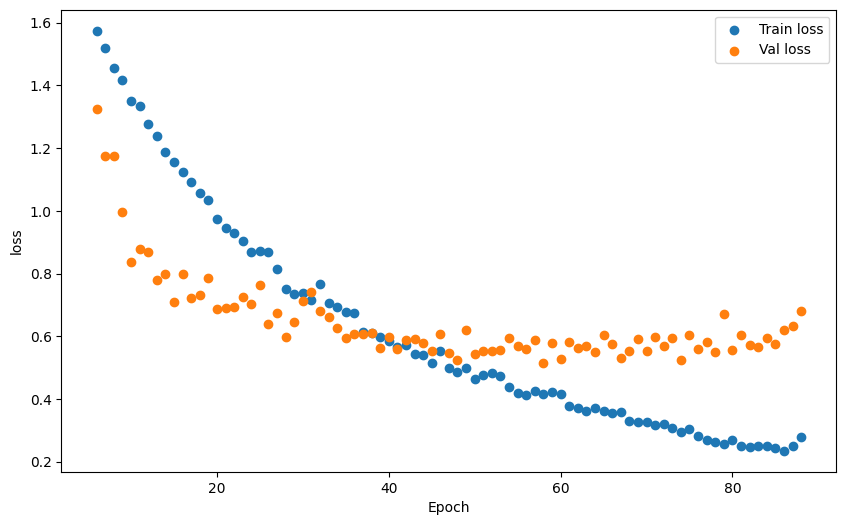

In [ ]:
# Plot training and validation loss versus epochs
epochs = range(1, len(history.history["val_loss"]) + 1)
min_loss = min(history.history["val_loss"])
print(f"min val_loss {round(min_loss,3)}")
plt.figure(figsize=(10, 6))
plt.scatter(epochs[5:], history.history["loss"][5:], label="Train loss")
plt.scatter(epochs[5:], history.history["val_loss"][5:], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

In [ ]:
# the augmented version of the validation bal_acc
y_pred_prob = model.predict(X_train, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
bal_acc  = balanced_accuracy_score(y_train, y_pred)
print("Validation_aug bal_acc score:", round(bal_acc,3))

Validation_aug bal_acc score: 0.918


In [193]:
y_pred_prob = model.predict(X_combined, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
bal_acc  = balanced_accuracy_score(y_combined, y_pred)
print("Training bal_acc score:", round(bal_acc,3))

Training bal_acc score: 0.903


In [194]:
y_pred_prob = model.predict(X_valid_aug, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
bal_acc  = balanced_accuracy_score(y_valid_aug, y_pred)
print("Validation_aug bal_acc score:", round(bal_acc,3))

Validation_aug bal_acc score: 0.485


In [ ]:
y_pred_prob = model.predict(X_valid, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
bal_acc  = balanced_accuracy_score(y_valid, y_pred)
print("Validation bal_acc score:", round(bal_acc,3))

Validation bal_acc score: 0.486


In [ ]:
## saving the model to use it after
# model.save("D:/Mallorn/models/model_3_v2.keras")